# __AIFAKER__

#### 모듈 모음

In [ ]:
!pip install scikit-image
!pip install torch torchvision matplotlib numpy
!pip install torch torchvision diffusers transformers accelerate matplotlib

## 노이즈 처리

__출력방식:__
- 원본 이미지, 노이즈 처리 이미지로 출력
- 노이즈 처리는 3단계로 구성됨
0.1, 0.3, 0.5 순서

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_korean_font():
    """한글 폰트 자동 설정"""
    font_candidates = ["NanumGothic", "Malgun Gothic", "AppleGothic"]  # Windows, Mac, Linux 폰트
    font_found = False

    for font in fm.findSystemFonts():
        font_name = fm.FontProperties(fname=font).get_name()
        if font_name in font_candidates:
            plt.rc("font", family=font_name)
            font_found = True
            print(f"✅ 한글 폰트 적용: {font_name}")
            break

    if not font_found:
        print("⚠️ 한글 폰트를 찾을 수 없습니다. 기본 폰트 사용.")

# 한글 폰트 설정 실행
set_korean_font()

✅ 한글 폰트 적용: Malgun Gothic


### StyleGAN

✅ 보호된 이미지 저장 완료: ./Output/001_1_SGN.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_2_SGN.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_3_SGN.jpg


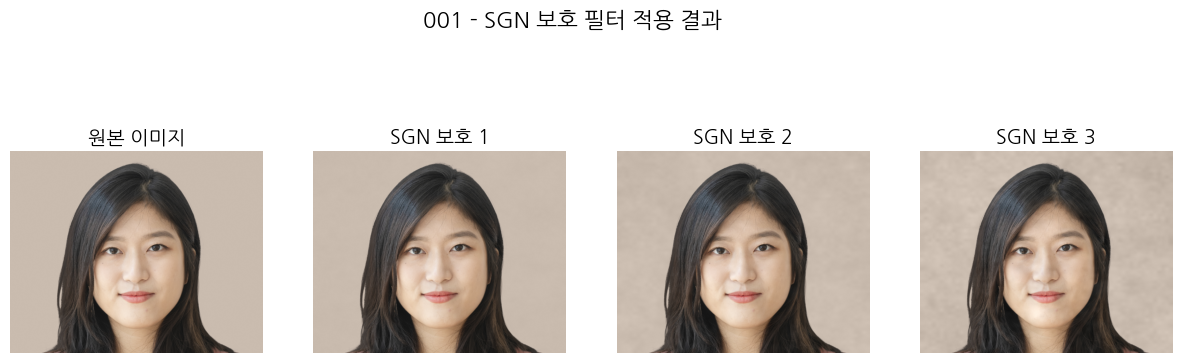

✅ 보호된 이미지 저장 완료: ./Output/002_1_SGN.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_2_SGN.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_3_SGN.jpg


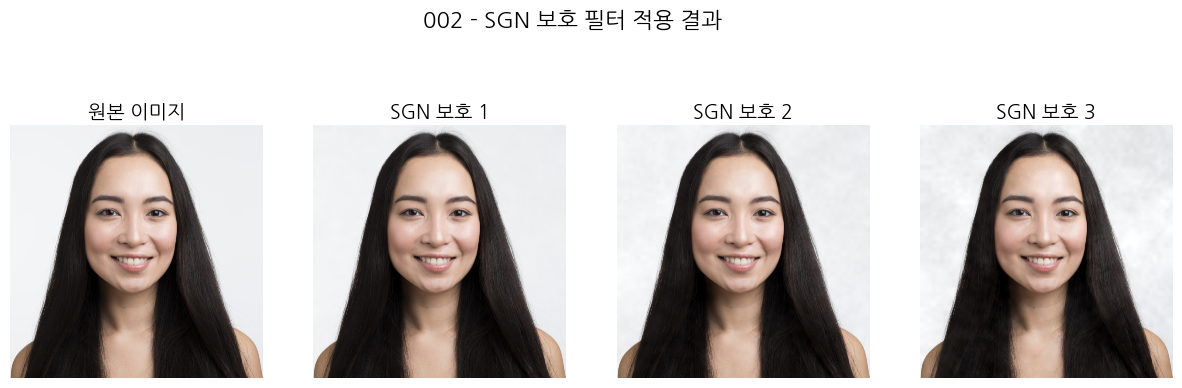

🎉 모든 StyleGAN 보호 이미지 저장 완료!


In [8]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

def generate_protective_noise(image_size, strength=0.03):
    """스타일GAN 기반 보호 노이즈 생성"""
    noise_layers = []
    for scale in [4, 8, 16, 32, 64]:
        if scale <= image_size[0] and scale <= image_size[1]:
            noise = torch.randn(1, 1, scale, scale)
            upsampled = torch.nn.functional.interpolate(
                noise, size=image_size, mode='bilinear', align_corners=False
            ).squeeze(0)
            noise_layers.append(upsampled)

    combined_noise = sum(noise_layers) / len(noise_layers)
    return combined_noise.expand(3, -1, -1) * strength

def protect_image(image_path, output_base, noise_strength):
    """이미지에 StyleGAN 기반 보호 노이즈 적용 및 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img)

    noise = generate_protective_noise((img_tensor.shape[1], img_tensor.shape[2]), strength=noise_strength)

    protected_img = img_tensor + noise
    protected_img = torch.clamp(protected_img, 0, 1)

    protected_pil = transforms.ToPILImage()(protected_img)
    output_path = f"{output_base}_SGN.jpg"
    protected_pil.save(output_path)
    print(f"✅ 보호된 이미지 저장 완료: {output_path}")

    return protected_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")

    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 보호 {i+1}", fontsize=14)
        axes[i + 1].axis("off")

    plt.suptitle(f"{img_name} - {model_name} 보호 필터 적용 결과", fontsize=16)
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.01, 0.03, 0.05)):
    """입력 폴더의 모든 이미지에 StyleGAN 보호 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))

    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    
    for img_path in image_paths:
        img_name, _ = os.path.splitext(os.path.basename(img_path))
        protected_images = []

        original = Image.open(img_path).convert("RGB")
        for i, noise_strength in enumerate(noise_levels, 1):
            output_base = os.path.join(output_dir, f"{img_name}_{i}")
            protected_pil = protect_image(img_path, output_base, noise_strength)
            protected_images.append(protected_pil)

        display_images(original, protected_images, img_name, "SGN")

    print("🎉 모든 StyleGAN 보호 이미지 저장 완료!")

# 실행
process_images()

### Stable Diffusion Noise

✅ 보호된 이미지 저장 완료: ./Output/001_1_SDN.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_2_SDN.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_3_SDN.jpg


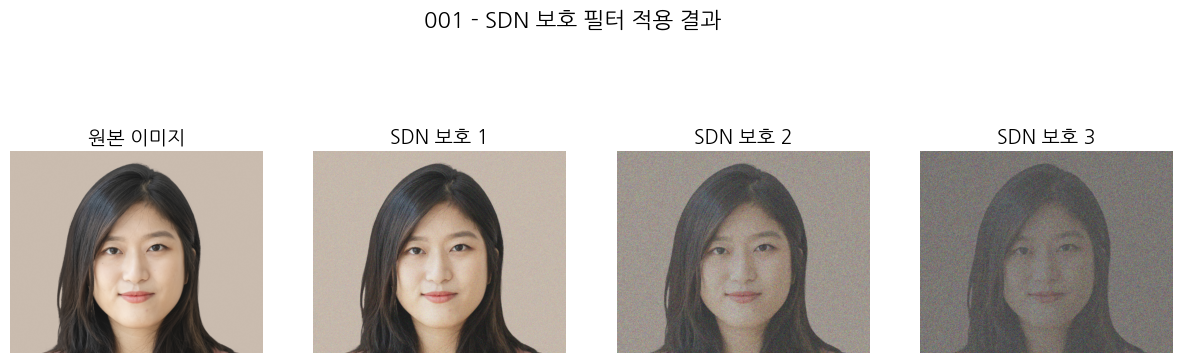

✅ 보호된 이미지 저장 완료: ./Output/002_1_SDN.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_2_SDN.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_3_SDN.jpg


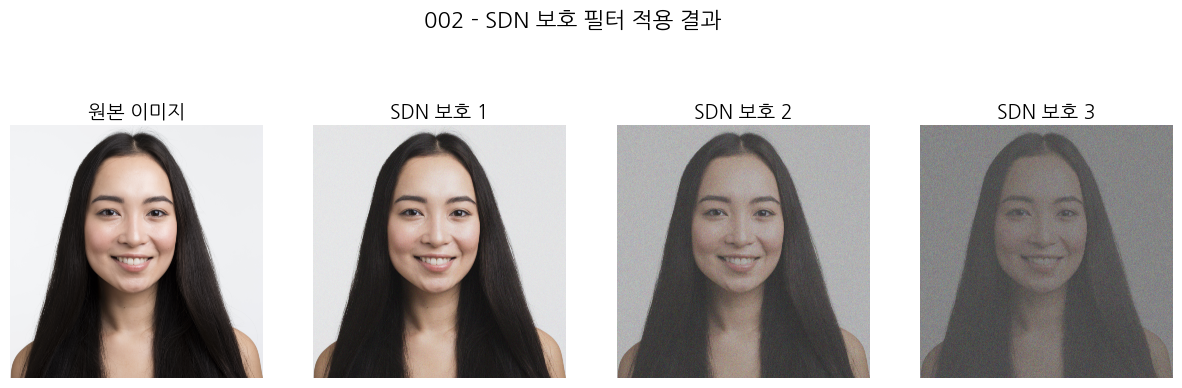

🎉 모든 Stable Diffusion 보호 이미지 저장 완료!


In [9]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from diffusers import DDPMScheduler

# 🔥 Stable Diffusion의 DDPMScheduler (Forward Diffusion 과정 사용)
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02, beta_schedule="scaled_linear")

def apply_stable_diffusion_noise(image_tensor, noise_level):
    """Stable Diffusion의 Forward Diffusion 과정에서 노이즈 추가"""
    timesteps = torch.tensor([int(noise_level * len(scheduler.timesteps))], dtype=torch.long).to(image_tensor.device)
    noise = torch.randn_like(image_tensor)
    noisy_image = scheduler.add_noise(image_tensor, noise, timesteps)
    return torch.clamp(noisy_image, 0, 1)

def protect_image(image_path, output_base, noise_level):
    """이미지에 Stable Diffusion 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    noisy_img_tensor = apply_stable_diffusion_noise(img_tensor, noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    output_path = f"{output_base}_SDN.jpg"
    noisy_pil.save(output_path)
    print(f"✅ 보호된 이미지 저장 완료: {output_path}")

    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")

    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 보호 {i+1}", fontsize=14)
        axes[i + 1].axis("off")

    plt.suptitle(f"{img_name} - {model_name} 보호 필터 적용 결과", fontsize=16)
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.1, 0.3, 0.5)):
    """입력 폴더의 모든 이미지에 Stable Diffusion 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))

    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    
    for img_path in image_paths:
        img_name, _ = os.path.splitext(os.path.basename(img_path))
        protected_images = []

        original = Image.open(img_path).convert("RGB")
        for i, noise_level in enumerate(noise_levels, 1):
            output_base = os.path.join(output_dir, f"{img_name}_{i}")
            protected_pil = protect_image(img_path, output_base, noise_level)
            protected_images.append(protected_pil)

        display_images(original, protected_images, img_name, "SDN")

    print("🎉 모든 Stable Diffusion 보호 이미지 저장 완료!")

# 실행
process_images()

### Denoising Diffusion Probabilistic Models

✅ 보호된 이미지 저장 완료: ./Output/001_1_DDPM.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_2_DDPM.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_3_DDPM.jpg


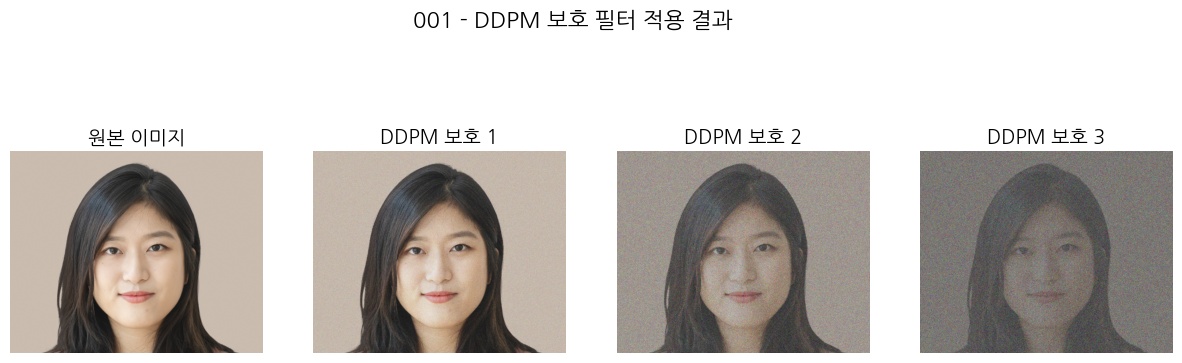

✅ 보호된 이미지 저장 완료: ./Output/002_1_DDPM.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_2_DDPM.jpg
✅ 보호된 이미지 저장 완료: ./Output/002_3_DDPM.jpg


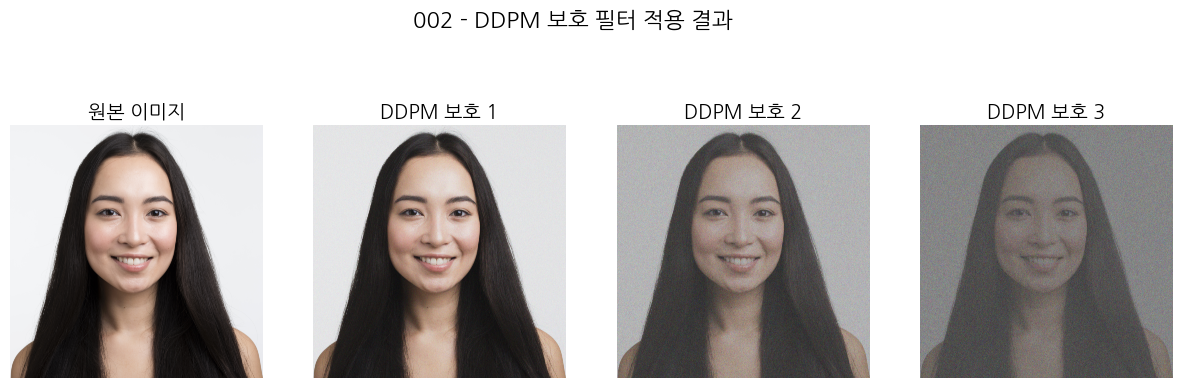

🎉 모든 DDPM 보호 이미지 저장 완료!


In [10]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from diffusers import DDPMScheduler

# 🔥 DDPM Forward Diffusion을 위한 스케줄러 설정
scheduler = DDPMScheduler(num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02, beta_schedule="scaled_linear")

def apply_ddpm_noise(image_tensor, noise_level):
    """DDPM Forward Diffusion 방식으로 노이즈 추가"""
    timesteps = torch.tensor([int(noise_level * len(scheduler.timesteps))], dtype=torch.long).to(image_tensor.device)
    noise = torch.randn_like(image_tensor)  # 가우시안 노이즈 생성
    noisy_image = scheduler.add_noise(image_tensor, noise, timesteps)  # 노이즈 적용
    return torch.clamp(noisy_image, 0, 1)  # 0~1 범위로 클램핑

def protect_image(image_path, output_base, noise_level):
    """이미지에 DDPM 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to("cuda" if torch.cuda.is_available() else "cpu")

    noisy_img_tensor = apply_ddpm_noise(img_tensor, noise_level)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    output_path = f"{output_base}_DDPM.jpg"
    noisy_pil.save(output_path)
    print(f"✅ 보호된 이미지 저장 완료: {output_path}")

    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")

    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 보호 {i+1}", fontsize=14)
        axes[i + 1].axis("off")

    plt.suptitle(f"{img_name} - {model_name} 보호 필터 적용 결과", fontsize=16)
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.1, 0.3, 0.5)):
    """입력 폴더의 모든 이미지에 DDPM 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))

    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    
    for img_path in image_paths:
        img_name, _ = os.path.splitext(os.path.basename(img_path))
        protected_images = []

        original = Image.open(img_path).convert("RGB")
        for i, noise_level in enumerate(noise_levels, 1):
            output_base = os.path.join(output_dir, f"{img_name}_{i}")
            protected_pil = protect_image(img_path, output_base, noise_level)
            protected_images.append(protected_pil)

        display_images(original, protected_images, img_name, "DDPM")

    print("🎉 모든 DDPM 보호 이미지 저장 완료!")

# 실행
process_images()


DDPM과 SDN 둘 다 같은 노이즈 추가 방식, 제거 방식만 다르므로 둘 중 하나만 쓰는 걸로

### Universal Adversarial Perturbations
FGSM(Fast Gradient Sign Method) 기반 (메모리 문제 해결될 때까지 사용금지)

✅ 보호된 이미지 저장 완료: ./Output/001_1_UAP.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_2_UAP.jpg
✅ 보호된 이미지 저장 완료: ./Output/001_3_UAP.jpg


c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acorn\anaconda3\envs\py3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Dej

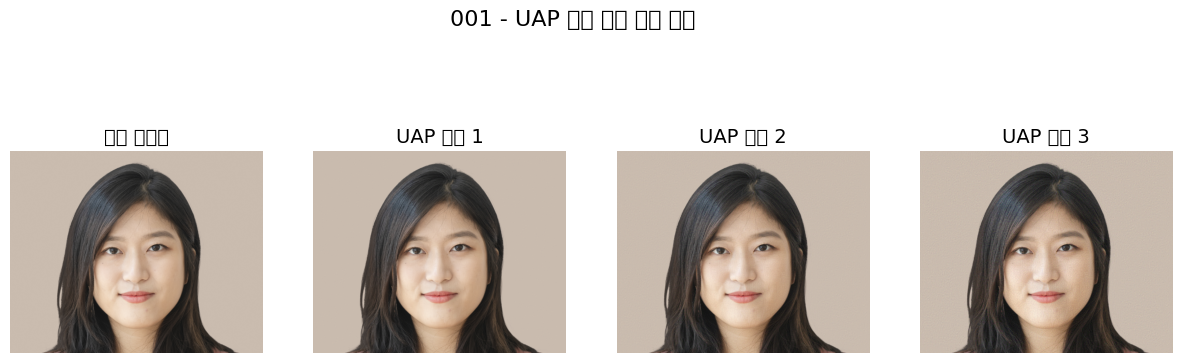

: 

In [1]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

# ⚡ 장치 설정 (GPU 가능 시 CUDA 사용)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔥 FGSM 기반 Universal Adversarial Perturbation 생성 함수
def generate_uap(model, images, epsilon=0.1):
    """FGSM을 사용하여 Universal Adversarial Perturbation 생성"""
    model.eval()
    images = images.to(device).detach().clone()  # ✅ requires_grad 제거 (메모리 누수 방지)
    images.requires_grad_()

    # 예측 결과 가져오기
    output = model(images)
    target = output.argmax(dim=1)  # 예측된 클래스

    # 손실 함수 설정
    loss_fn = torch.nn.CrossEntropyLoss()
    loss = loss_fn(output, target)

    # 그래디언트 계산
    model.zero_grad()
    loss.backward()

    # FGSM 방식으로 적대적 노이즈 생성
    perturbation = epsilon * images.grad.sign()
    
    # 메모리 정리 (CUDA 사용 시)
    torch.cuda.empty_cache()
    
    return perturbation.detach()

def apply_uap(image_tensor, uap):
    """생성된 UAP를 이미지에 적용"""
    perturbed_image = image_tensor + uap
    return torch.clamp(perturbed_image, 0, 1)  # 0~1 범위로 클램핑

def protect_image(image_path, output_base, epsilon):
    """UAP 기반 보호 노이즈 적용 후 저장"""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(device)

    # Pre-trained ResNet 모델 로드 (weights 사용)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(device)
    uap = generate_uap(model, img_tensor, epsilon)

    # 노이즈 적용
    noisy_img_tensor = apply_uap(img_tensor, uap)
    noisy_pil = transforms.ToPILImage()(noisy_img_tensor.squeeze(0).cpu())

    output_path = f"{output_base}_UAP.jpg"
    noisy_pil.save(output_path)
    print(f"✅ 보호된 이미지 저장 완료: {output_path}")

    return noisy_pil

def display_images(original, protected_list, img_name, model_name):
    """보호 전/후 이미지 비교 출력"""
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    axes[0].imshow(original)
    axes[0].set_title("원본 이미지", fontsize=14)
    axes[0].axis("off")

    for i, protected in enumerate(protected_list):
        axes[i + 1].imshow(protected)
        axes[i + 1].set_title(f"{model_name} 보호 {i+1}", fontsize=14)
        axes[i + 1].axis("off")

    plt.suptitle(f"{img_name} - {model_name} 보호 필터 적용 결과", fontsize=16)
    plt.show()

def process_images(input_dir="./Input/", output_dir="./Output/", noise_levels=(0.01, 0.03, 0.05)):
    """입력 폴더의 모든 이미지에 UAP 기반 노이즈 적용"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_formats = ("*.jpg", "*.jpeg", "*.png")
    image_paths = []
    for fmt in image_formats:
        image_paths.extend(glob.glob(os.path.join(input_dir, fmt)))

    if not image_paths:
        print("⚠️ 변환할 이미지가 없습니다.")
        return
    
    for img_path in image_paths:
        img_name, _ = os.path.splitext(os.path.basename(img_path))
        protected_images = []

        original = Image.open(img_path).convert("RGB")
        for i, epsilon in enumerate(noise_levels, 1):
            output_base = os.path.join(output_dir, f"{img_name}_{i}")
            protected_pil = protect_image(img_path, output_base, epsilon)
            protected_images.append(protected_pil)

        display_images(original, protected_images, img_name, "UAP")

    print("🎉 모든 UAP 보호 이미지 저장 완료!")

# 실행
process_images()

### PGD(Projected Gradient Descent)

## 검증

### PSNR (Peak Signal-to-Noise Ratio) & SSIM (Structural Similarity) 계산

__목표:__

- PSNR (신호 대 잡음비): 원본과 변형된 이미지의 유사도 측정 (값이 클수록 원본과 유사)
- SSIM (구조적 유사도): 이미지의 구조적 차이를 정량화 (값이 1에 가까울수록 원본과 유사)
검증 방법:

- PSNR이 낮으면 노이즈가 강하게 적용된 것
- SSIM이 낮으면 원본과 구조적으로 차이가 많아진 것

In [ ]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim

def calculate_psnr_ssim(original, noisy):
    """PSNR 및 SSIM 계산"""
    original = np.array(original.convert("L"))  # 흑백 변환
    noisy = np.array(noisy.convert("L"))  # 흑백 변환

    # PSNR 계산
    mse = np.mean((original - noisy) ** 2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

    # SSIM 계산
    ssim_value = ssim(original, noisy, data_range=noisy.max() - noisy.min())

    return psnr, ssim_value

def validate_output(original, protected_list):
    """각 보호된 이미지에 대해 PSNR 및 SSIM 평가"""
    for i, protected in enumerate(protected_list):
        psnr, ssim_value = calculate_psnr_ssim(original, protected)
        print(f"🔹 노이즈 단계 {i+1}: PSNR={psnr:.2f}, SSIM={ssim_value:.4f}")

### Robustness Test

__목표:__

- 원본 이미지와 노이즈 이미지가 AI 모델에서 같은 클래스로 예측되는지 확인
- 이미지 분류 모델 (ResNet, EfficientNet) 등을 사용해 비교

__검증 방법:__

- Pre-trained 모델 (ResNet50 등) 사용
- 원본 vs. 노이즈 이미지 각각 예측
- 노이즈 강도가 올라갈수록 예측 정확도가 낮아지는지 확인

In [23]:
import torch
import torchvision.models as models
import torchvision.transforms as T

# Pre-trained ResNet 모델 로드
model = models.resnet50(pretrained=True)
model.eval()

def predict_image(image):
    """이미지를 ResNet 모델을 사용하여 분류"""
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0)  # 배치 차원 추가
    with torch.no_grad():
        output = model(image_tensor)
    
    return torch.argmax(output).item()

def evaluate_model_robustness(original, protected_list):
    """원본 및 보호된 이미지의 분류 결과 비교"""
    original_label = predict_image(original)
    print(f"🖼️ 원본 이미지 예측 라벨: {original_label}")

    for i, protected in enumerate(protected_list):
        noisy_label = predict_image(protected)
        print(f"🔹 노이즈 {i+1}단계 예측 라벨: {noisy_label}")

### 통합 검증 모델

##### __출력 방식__
1. 원본 이미지 검증 수치
2. 원본 이미지
3. 모델
4. 노이즈 처리 이미지
5. 노이즈 검증 수치
6. 모델 끝나면 3번부터 다시 다른 모델 검증 진행
7. 모든 모델 검증 후 다음 이미지 검증


📌 **001 (원본 이미지) 검증 결과**
🔍 AI 모델 예측: 903


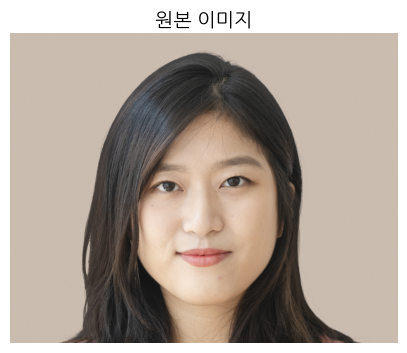


🎨 **DDPM 모델**


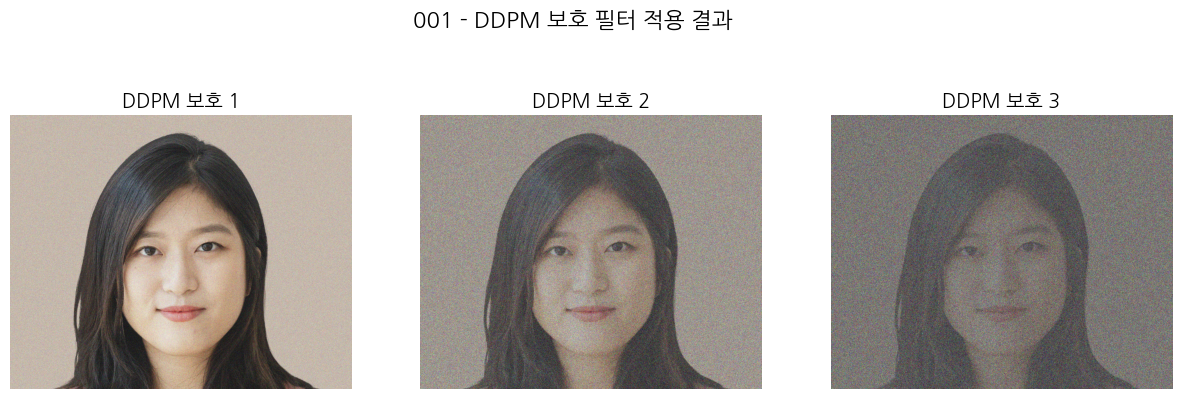

📌 **DDPM_1**
  - PSNR: 28.24
  - SSIM: 0.1204
  - AI 모델 예측: 903

📌 **DDPM_2**
  - PSNR: 27.91
  - SSIM: 0.0264
  - AI 모델 예측: 903

📌 **DDPM_3**
  - PSNR: 27.88
  - SSIM: 0.0150
  - AI 모델 예측: 501


🎨 **SDN 모델**


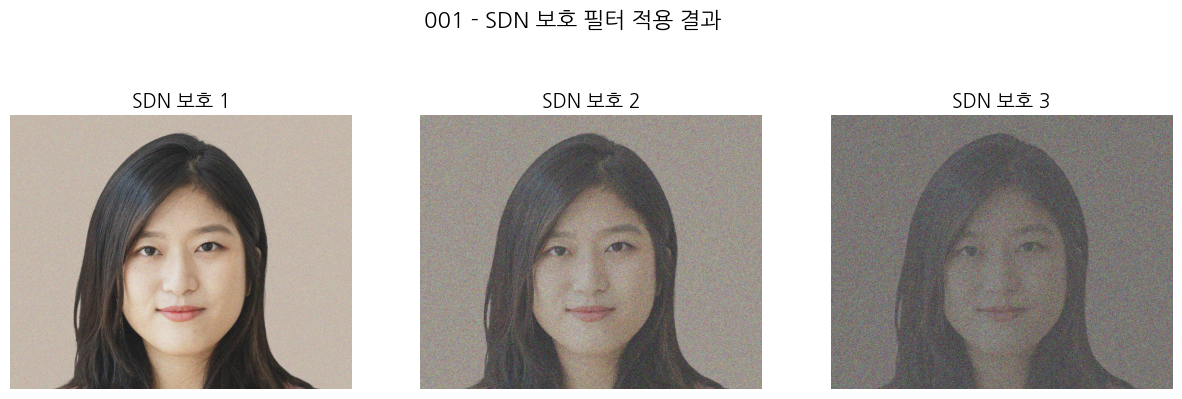

📌 **SDN_1**
  - PSNR: 28.24
  - SSIM: 0.1205
  - AI 모델 예측: 903

📌 **SDN_2**
  - PSNR: 27.92
  - SSIM: 0.0265
  - AI 모델 예측: 903

📌 **SDN_3**
  - PSNR: 27.88
  - SSIM: 0.0151
  - AI 모델 예측: 501


🎨 **SGN 모델**


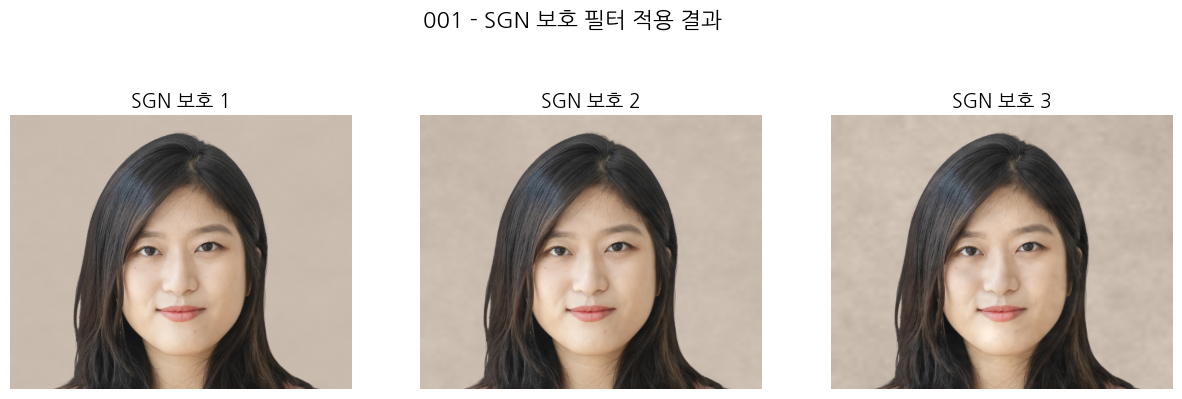

📌 **SGN_1**
  - PSNR: 40.70
  - SSIM: 0.9553
  - AI 모델 예측: 459

📌 **SGN_2**
  - PSNR: 38.00
  - SSIM: 0.9541
  - AI 모델 예측: 445

📌 **SGN_3**
  - PSNR: 34.98
  - SSIM: 0.9556
  - AI 모델 예측: 445


🎨 **UAP 모델**


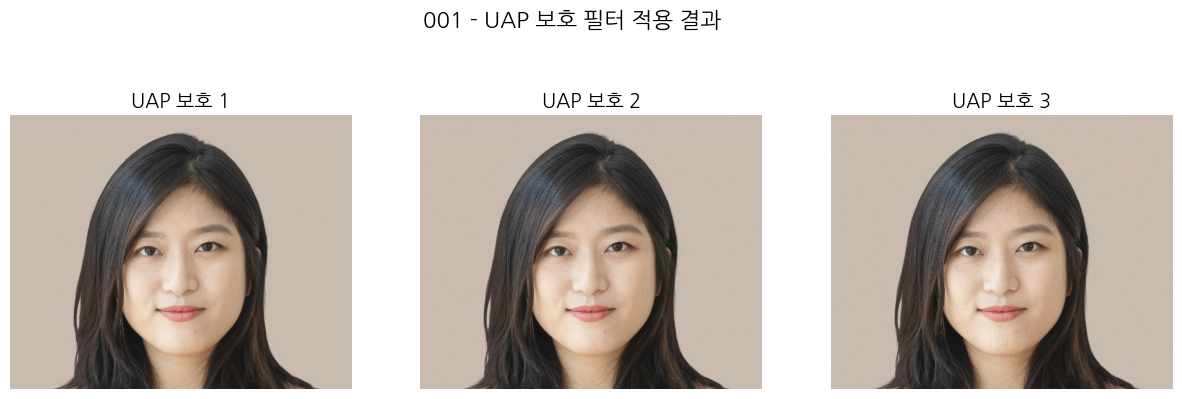

📌 **UAP_1**
  - PSNR: 39.47
  - SSIM: 0.9253
  - AI 모델 예측: 903

📌 **UAP_2**
  - PSNR: 32.36
  - SSIM: 0.6861
  - AI 모델 예측: 903

📌 **UAP_3**
  - PSNR: 29.31
  - SSIM: 0.4310
  - AI 모델 예측: 903


📌 **002 (원본 이미지) 검증 결과**
🔍 AI 모델 예측: 903


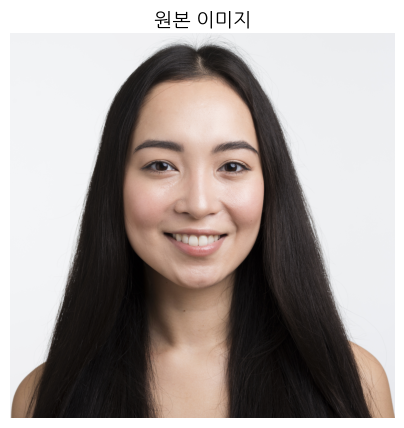


🎨 **DDPM 모델**


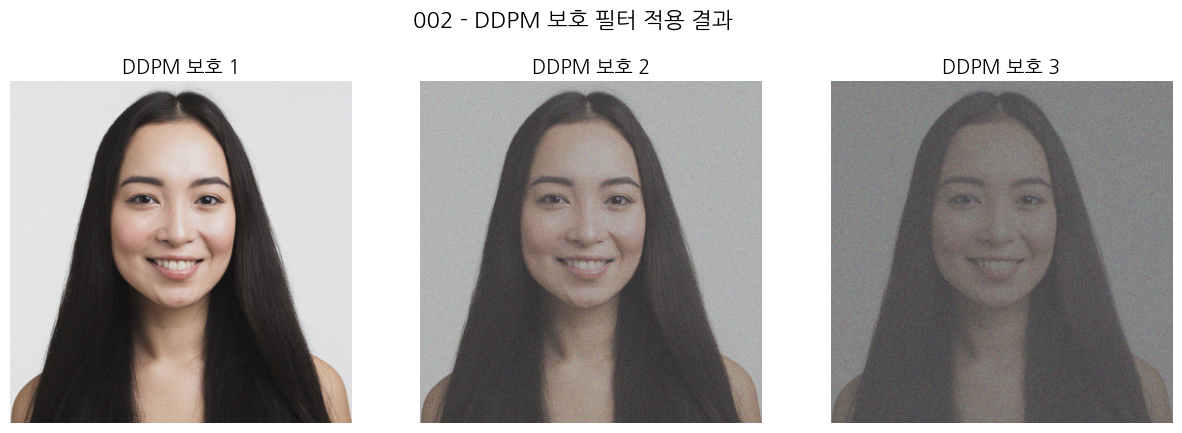

📌 **DDPM_1**
  - PSNR: 28.49
  - SSIM: 0.1267
  - AI 모델 예측: 903

📌 **DDPM_2**
  - PSNR: 28.12
  - SSIM: 0.0219
  - AI 모델 예측: 903

📌 **DDPM_3**
  - PSNR: 28.00
  - SSIM: 0.0119
  - AI 모델 예측: 501


🎨 **SDN 모델**


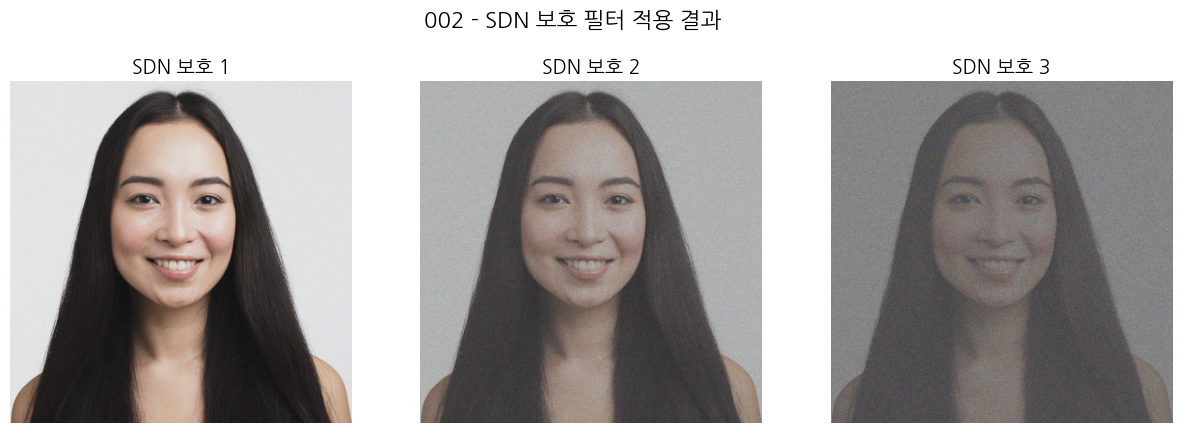

📌 **SDN_1**
  - PSNR: 28.49
  - SSIM: 0.1267
  - AI 모델 예측: 903

📌 **SDN_2**
  - PSNR: 28.12
  - SSIM: 0.0219
  - AI 모델 예측: 903

📌 **SDN_3**
  - PSNR: 28.00
  - SSIM: 0.0119
  - AI 모델 예측: 501


🎨 **SGN 모델**


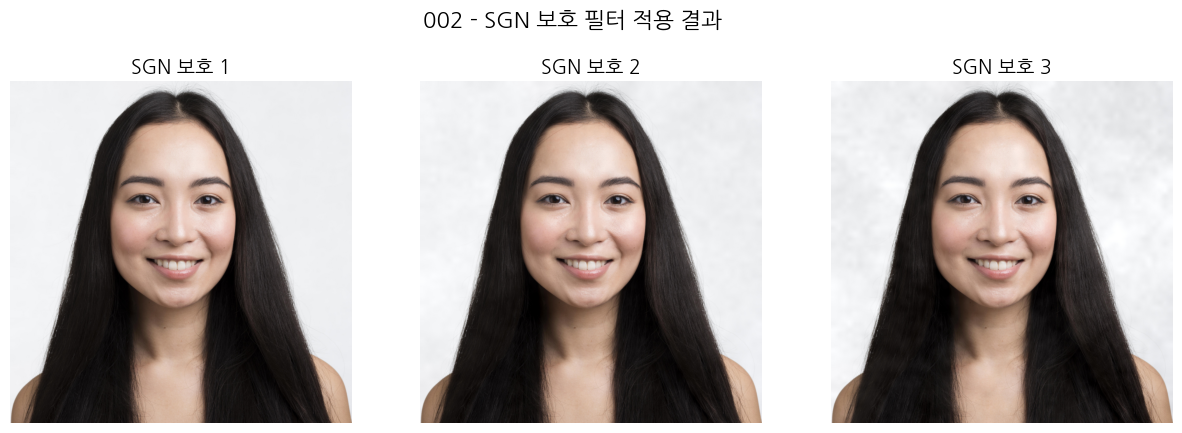

📌 **SGN_1**
  - PSNR: 43.52
  - SSIM: 0.9806
  - AI 모델 예측: 903

📌 **SGN_2**
  - PSNR: 39.69
  - SSIM: 0.9773
  - AI 모델 예측: 903

📌 **SGN_3**
  - PSNR: 34.35
  - SSIM: 0.9710
  - AI 모델 예측: 445



In [14]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import cv2
from skimage.metrics import structural_similarity as ssim

# ⚡ 장치 설정 (GPU 가능 시 CUDA 사용)
device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔥 Pre-trained AI 모델 (ResNet50) 로드 (PyTorch 최신 버전 대응)
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1).to(device)
model.eval()

def calculate_psnr_ssim(original, noisy):
    """PSNR 및 SSIM 계산"""
    original = np.array(original.convert("L"))  # 흑백 변환
    noisy = np.array(noisy.convert("L"))  # 흑백 변환

    # PSNR 계산
    mse = np.mean((original - noisy) ** 2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse)) if mse > 0 else float('inf')

    # SSIM 계산
    ssim_value = ssim(original, noisy, data_range=noisy.max() - noisy.min())

    return psnr, ssim_value

def predict_image(image):
    """이미지를 ResNet 모델을 사용하여 분류"""
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)  # 배치 차원 추가
    with torch.no_grad():
        output = model(image_tensor)
    return torch.argmax(output).item()

def extract_model_name(filename):
    """출력 파일명에서 모델명 추출 (_1_SGN.jpg → SGN)"""
    parts = filename.split("_")
    return parts[-1].split(".")[0]  # 확장자 제거

def validate_images(input_dir="./Output/"):
    """모든 이미지에 대해 PSNR, SSIM, AI 모델 예측 수행 및 출력"""
    image_dict = {}  # {원본이미지: {모델명: [노이즈 이미지1, 2, 3]}}

    # 이미지 파일 탐색
    image_paths = glob.glob(os.path.join(input_dir, "*_*_*.jpg"))  # _1_SGN.jpg 같은 형식
    for img_path in image_paths:
        img_name, _ = os.path.splitext(os.path.basename(img_path))  # 파일명 추출
        base_name = "_".join(img_name.split("_")[:-2])  # 원본 이미지명
        model_name = extract_model_name(img_name)  # 모델명
        noise_level = int(img_name.split("_")[-2])  # 노이즈 단계

        if base_name not in image_dict:
            image_dict[base_name] = {}
        if model_name not in image_dict[base_name]:
            image_dict[base_name][model_name] = {}

        image_dict[base_name][model_name][noise_level] = img_path  # 정렬

    # 검증 수행
    for base_name, models in image_dict.items():
        print(f"\n📌 **{base_name} (원본 이미지) 검증 결과**")
        original_img_path = os.path.join("./Input/", base_name + ".jpg")
        
        if not os.path.exists(original_img_path):
            print(f"⚠️ 원본 이미지 '{base_name}.jpg'가 ./Input/ 폴더에 없습니다!")
            continue

        original_img = Image.open(original_img_path).convert("RGB")

        # 원본 AI 예측
        original_ai = predict_image(original_img)
        print(f"🔍 AI 모델 예측: {original_ai}")

        # 원본 이미지 출력
        fig, axes = plt.subplots(1, 1, figsize=(5, 5))
        axes.imshow(original_img)
        axes.set_title("원본 이미지", fontsize=14)
        axes.axis("off")
        plt.show()

        # 각 모델별 출력
        for model_name, noise_dict in models.items():
            print(f"\n🎨 **{model_name} 모델**")
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            protected_list = []
            psnr_ssim_values = {}
            ai_results = {}

            for i in range(1, 4):
                noisy_img = Image.open(noise_dict[i]).convert("RGB")
                protected_list.append(noisy_img)

                # PSNR & SSIM 계산
                psnr, ssim_value = calculate_psnr_ssim(original_img, noisy_img)
                psnr_ssim_values[i] = (psnr, ssim_value)

                # AI 모델 예측
                ai_results[i] = predict_image(noisy_img)

                axes[i-1].imshow(noisy_img)
                axes[i-1].set_title(f"{model_name} 보호 {i}", fontsize=14)
                axes[i-1].axis("off")

            plt.suptitle(f"{base_name} - {model_name} 보호 필터 적용 결과", fontsize=16)
            plt.show()

            # PSNR, SSIM, AI 예측 결과를 이미지별로 출력
            for i in range(1, 4):
                psnr, ssim_value = psnr_ssim_values[i]
                ai_label = ai_results[i]

                print(f"📌 **{model_name}_{i}**")
                print(f"  - PSNR: {psnr:.2f}")
                print(f"  - SSIM: {ssim_value:.4f}")
                print(f"  - AI 모델 예측: {ai_label}\n")

# 실행
validate_images()